In [50]:
from langchain_openai import ChatOpenAI
import os
from dotenv import load_dotenv
load_dotenv()
llm=ChatOpenAI(model="gpt-5-mini")
llm

ChatOpenAI(metadata={'lc_versions': {'langchain-core': '1.4.8', 'langchain': '1.3.10', 'langchain-openai': '1.3.2'}}, output_version=None, profile={'name': 'GPT-5 Mini', 'release_date': '2025-08-07', 'last_updated': '2025-08-07', 'open_weights': False, 'max_input_tokens': 272000, 'max_output_tokens': 128000, 'text_inputs': True, 'image_inputs': True, 'audio_inputs': False, 'video_inputs': False, 'text_outputs': True, 'image_outputs': False, 'audio_outputs': False, 'video_outputs': False, 'reasoning_output': True, 'tool_calling': True, 'structured_output': True, 'attachment': True, 'temperature': False, 'image_url_inputs': True, 'pdf_inputs': True, 'pdf_tool_message': True, 'image_tool_message': True, 'tool_choice': True, 'tool_call_streaming': True}, client=<openai.resources.chat.completions.completions.Completions object at 0x1161674d0>, async_client=<openai.resources.chat.completions.completions.AsyncCompletions object at 0x118b6d590>, root_client=<openai.OpenAI object at 0x117447ce0

In [51]:
from langchain.tools import tool

In [52]:
@tool
def tool_duck_duck_go_search(query:str) -> str:
    """use  this tool when we need to answer questions about current events
    what is happening in current time, news and event around the world """
    #tool-A
    from langchain_community.tools import DuckDuckGoSearchRun
    search=DuckDuckGoSearchRun()
    response=search.invoke(query)
    return response

In [53]:
tool_duck_duck_go_search.invoke("what is the name of Founder of Pakistan")

'Key player in nurturing religious support for the creation of Pakistan, 13 Founder of Jamiat Ulema-e-Islam , raised the flag of Pakistan for the ... ... the fourth and final stage, he emerged as the founder of Pakistan where he is revered as Quaid-i-Azam , the great leader, and Baba-i-Qaum , the father ... Karachi : In a recent statement, Faraz ur Rehman, Chairman & Founder of Pakistan Business Group, highlighted the ongoing efforts in Pakistan to ... ... these very ideas to form Pakistan in 1947, evident as he says “Let us lay the foundation of our democracy on the basis of truly Islamic ideals and ... Biography: Jinnah is revered in Pakistan as the Father of the Nation and his birthday is a national holiday in the country.'

In [54]:
@tool
def tool_wiki_pedia_search(query: str) -> str:
    #tool-B

    """use  this tool when we need to answer questions about person
    use wekipida to reply"""

    from langchain_community.tools import  WikipediaQueryRun
    from langchain_community.utilities import WikipediaAPIWrapper

    wikipedia = WikipediaQueryRun (api_wrapper=WikipediaAPIWrapper ())
    res_wiki=wikipedia.invoke(query)
    return res_wiki

In [55]:
tool_wiki_pedia_search.invoke("who is obama")

JSONDecodeError: Expecting value: line 1 column 1 (char 0)

In [56]:
from langchain_core.tools import tool
import arxiv

@tool
def tool_arxiv_search(query: str, max_results: int = 3) -> list:
    #tool-C
    """
    use toll to give the top Search paper, arXiv tool give
      papers based on a query and return top results.
    """

    client = arxiv.Client()

    search = arxiv.Search(
        query=query,
        max_results=max_results,
        sort_by=arxiv.SortCriterion.SubmittedDate
    )

    results = client.results(search)

    papers = []
    for r in results:
        papers.append({
            "title": r.title,
            "published": str(r.published),
            "summary": r.summary[:300],
            "link": r.entry_id
        })

    return papers

In [57]:
tool_arxiv_search.invoke({"query": "deep learning natural language processing", "max_results": 2})

HTTPError: Page request resulted in HTTP 301: None (http://export.arxiv.org/api/query?search_query=deep+learning+natural+language+processing&id_list=&sortBy=submittedDate&sortOrder=descending&start=0&max_results=2)

In [ ]:
#create the tool for personal information
#tool-D
@tool
def tool_peroanl_info(query:str)->str:
    """Search personal information from database and return
    a person's name, age, and location. what is education and working domain"""

    infos=[{
        "name":"Junaid",
        "age":"20",
        "location":"Germany",
        "education":"bssc",
        "work":"IT"

    },
    {   "name":"bilal",
        "age":"22",
        "location":"Dutchland",
        "education":"bsse",
        "work":"non IT"
        }]
    
    for info in infos:
        if info["name"].lower()==query.lower():
            #return f"{info["name"]} is {info["age"]} and live in {info["location"]}"
            return f"{info['name']} is {info['age']} and lives in {info['location']}"
    return "no information"


In [ ]:
tool_peroanl_info.invoke("bilal")

'bilal is 22 and lives in Dutchland'

In [ ]:
#now tool is created now we will bind these tool in llm

In [ ]:
llm=ChatOpenAI(model="gpt-5-mini")
llm
#llm is created

ChatOpenAI(metadata={'lc_versions': {'langchain-core': '1.4.8', 'langchain': '1.3.10', 'langchain-openai': '1.3.2'}}, output_version=None, profile={'name': 'GPT-5 Mini', 'release_date': '2025-08-07', 'last_updated': '2025-08-07', 'open_weights': False, 'max_input_tokens': 272000, 'max_output_tokens': 128000, 'text_inputs': True, 'image_inputs': True, 'audio_inputs': False, 'video_inputs': False, 'text_outputs': True, 'image_outputs': False, 'audio_outputs': False, 'video_outputs': False, 'reasoning_output': True, 'tool_calling': True, 'structured_output': True, 'attachment': True, 'temperature': False, 'image_url_inputs': True, 'pdf_inputs': True, 'pdf_tool_message': True, 'image_tool_message': True, 'tool_choice': True, 'tool_call_streaming': True}, client=<openai.resources.chat.completions.completions.Completions object at 0x115dcf390>, async_client=<openai.resources.chat.completions.completions.AsyncCompletions object at 0x115dcf250>, root_client=<openai.OpenAI object at 0x115dcec10

In [ ]:
if os.path.exists("/Users/bilal/Downloads/AI/2-RAG/db"):
    print("connection is ok")
else:
    print("connection is not active")



connection is ok


In [ ]:
@tool
def tool_rag(query: str)-> str:
    """use this tool when you need to answer questions based on NovaSpehere organization's documentatios"""
    from langchain_community.vectorstores import Chroma
    from langchain_openai import OpenAIEmbeddings
    embed_model=OpenAIEmbeddings(model="text-embedding-3-small")
    path_db="../2-RAG/db"
    chroma_db_connection=Chroma(persist_directory=path_db,embedding_function=embed_model)



    #1-retrive relevant documents from the vectore store
    relevent_docs=chroma_db_connection.similarity_search(query,k=2)
    relevent_docs_content= "\n".join([doc.page_content for doc in relevent_docs])
    return relevent_docs_content


In [ ]:
tool_rag.invoke("what is novs")

/var/folders/2z/pqpq9wcs0dv4jfbgkp96j3780000gn/T/ipykernel_12515/3663827809.py:8: LangChainDeprecationWarning: The class `Chroma` was deprecated in LangChain 0.2.9 and will be removed in 1.0. An updated version of the class exists in the `langchain-chroma package and should be used instead. To use it run `pip install -U `langchain-chroma` and import as `from `langchain_chroma import Chroma``.
  chroma_db_connection=Chroma(persist_directory=path_db,embedding_function=embed_model)


'NovaSphere Technologies is a fictional organization created to represent a modern data\nNovaSphere Technologies is a fictional organization created to represent a modern data'

In [82]:
@tool
def tool_rag_semantic(query: str)-> str:
    """use this tool when you need to answer questions based on NovaSpehere organization's documentatios"""
    from langchain_community.vectorstores import Chroma
    from langchain_openai import OpenAIEmbeddings
    embed_model=OpenAIEmbeddings(model="text-embedding-3-small")
    path_db2="./chroma_db_semantic"
    chroma_db_connection=Chroma(persist_directory=path_db2,embedding_function=embed_model)



    #1-retrive relevant documents from the vectore store
    relevent_docs=chroma_db_connection.similarity_search(query,k=2)
    relevent_docs_content= "\n".join([doc.page_content for doc in relevent_docs])
    return relevent_docs_content


In [83]:
tool_rag_semantic.invoke("When was NovaSphere Organization founded?")

'NovaSphere Technologies is a fictional organization created to represent a modern data \nand technology company that has grown gradually over the years. The organization was \nfounded in 2016 by a small group of software engineers who strongly believed that data \nwould become one of the most valuable assets for every business in the future.\nThe founders also started planning \nthe next stage of growth, which included expanding into new regions and working with \ninternational clients. Today, NovaSphere Technologies is considered a reliable organization that provides data \nengineering and analytics services to companies from different industries such as finance, \nhealthcare, retail, and e-commerce. Even though the company has grown significantly \nsince 2016, the original vision has not changed. The focus is still on learning continuously, \nimproving the quality of work, and helping organizations make better decisions using data. The company believes that the future of business wi

In [ ]:
# to bind , we need bind tool kit

In [84]:
tool_kit=[

    tool_duck_duck_go_search,
    tool_wiki_pedia_search,
    tool_arxiv_search,
    tool_peroanl_info,
    #tool_rag ,
    tool_rag_semantic

]

In [85]:
tool_kit

[StructuredTool(name='tool_duck_duck_go_search', description='use  this tool when we need to answer questions about current events\nwhat is happening in current time, news and event around the world', args_schema=<class 'langchain_core.utils.pydantic.tool_duck_duck_go_search'>, func=<function tool_duck_duck_go_search at 0x118c28ae0>),
 StructuredTool(name='tool_wiki_pedia_search', description='use  this tool when we need to answer questions about person\nuse wekipida to reply', args_schema=<class 'langchain_core.utils.pydantic.tool_wiki_pedia_search'>, func=<function tool_wiki_pedia_search at 0x118c29620>),
 StructuredTool(name='tool_arxiv_search', description='use toll to give the top Search paper, arXiv tool give\n  papers based on a query and return top results.', args_schema=<class 'langchain_core.utils.pydantic.tool_arxiv_search'>, func=<function tool_arxiv_search at 0x118bb8680>),
 StructuredTool(name='tool_peroanl_info', description="Search personal information from database and

In [86]:
llm_bind=llm.bind_tools(tool_kit)
llm_bind
#. bind tool that allow to bind the tool with llm

_ChatModelBinding(bound=ChatOpenAI(metadata={'lc_versions': {'langchain-core': '1.4.8', 'langchain': '1.3.10', 'langchain-openai': '1.3.2'}}, output_version=None, profile={'name': 'GPT-5 Mini', 'release_date': '2025-08-07', 'last_updated': '2025-08-07', 'open_weights': False, 'max_input_tokens': 272000, 'max_output_tokens': 128000, 'text_inputs': True, 'image_inputs': True, 'audio_inputs': False, 'video_inputs': False, 'text_outputs': True, 'image_outputs': False, 'audio_outputs': False, 'video_outputs': False, 'reasoning_output': True, 'tool_calling': True, 'structured_output': True, 'attachment': True, 'temperature': False, 'image_url_inputs': True, 'pdf_inputs': True, 'pdf_tool_message': True, 'image_tool_message': True, 'tool_choice': True, 'tool_call_streaming': True}, client=<openai.resources.chat.completions.completions.Completions object at 0x1161674d0>, async_client=<openai.resources.chat.completions.completions.AsyncCompletions object at 0x118b6d590>, root_client=<openai.Open

In [87]:
#now i will call the llm and ask the age of bilal, it will pick the information but not final and give suggestion
#to solve this we need agent , it will works as loop and fectch the exact information
#this is reason and act, we use react agent class in llm

In [88]:
llm_bind.invoke("what the current location of bilal in database")

AIMessage(content='', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 91, 'prompt_tokens': 332, 'total_tokens': 423, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 64, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-5-mini-2025-08-07', 'system_fingerprint': None, 'id': 'chatcmpl-Du0fPw8XZzG347sdRIWDe126J7Xzn', 'service_tier': 'default', 'finish_reason': 'tool_calls', 'logprobs': None}, id='lc_run--019ef5dc-1aa4-7940-9062-38a3f9474655-0', tool_calls=[{'name': 'tool_peroanl_info', 'args': {'query': 'bilal'}, 'id': 'call_P2iVSwRPGueHE2BGUT9qnU10', 'type': 'tool_call'}], invalid_tool_calls=[], usage_metadata={'input_tokens': 332, 'output_tokens': 91, 'total_tokens': 423, 'input_token_details': {'audio': 0, 'cache_read': 0}, 'output_token_details': {'audio': 0, 'reasoning': 64}})

In [89]:
llm_bind = llm.bind_tools(tool_kit)

response = llm_bind.invoke("what is the professioanl of person name is bilal? His location is Dutchland")
print(response)

content='I don’t have enough information to identify “Bilal.” There are many people with that name. A couple quick clarifying questions before I search:\n\n- Do you mean “Dutchland” as the Netherlands or “Deutschland” (Germany)?\n- Can you provide a last name, city, company, age, or any other identifier (or a link)?\n- Is this a public figure or a private person, and do you want me to search public sources for their professional info?\n\nIf you confirm those details I can look it up (or guide you how to find it).' additional_kwargs={'refusal': None} response_metadata={'token_usage': {'completion_tokens': 572, 'prompt_tokens': 342, 'total_tokens': 914, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 448, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-5-mini-2025-08-07', 'system_fingerprint': None, 'id': 'chatcmpl-Du0fT5wAWjNcWo91EgiS1

In [90]:
#reAct Agent

In [91]:
from langchain.agents import create_agent

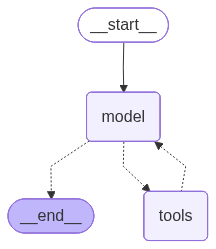

In [92]:
my_agent=create_agent(llm_bind, tools=tool_kit)
my_agent

In [93]:
my_agent.invoke(
{"messages":[{"role": "user", "content":"what is the education of person name is junaid whose location is Germany and bilal is public figure and work as IT}"
}]})

{'messages': [HumanMessage(content='what is the education of person name is junaid whose location is Germany and bilal is public figure and work as IT}', additional_kwargs={}, response_metadata={}, id='1bd0a8fd-d5fc-4873-9761-01fb4da7494e'),
  AIMessage(content='', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 163, 'prompt_tokens': 349, 'total_tokens': 512, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 128, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-5-mini-2025-08-07', 'system_fingerprint': None, 'id': 'chatcmpl-Du0fce6TxP6NKU2jUYMt7uB27MEyN', 'service_tier': 'default', 'finish_reason': 'tool_calls', 'logprobs': None}, id='lc_run--019ef5dc-4ee0-7e73-9570-c64413f66564-0', tool_calls=[{'name': 'tool_peroanl_info', 'args': {'query': 'junaid location Germany; bilal public figure IT'}, 

In [94]:
from langchain_core.messages import HumanMessage

my_agent.invoke({
    "messages": [HumanMessage(content="WHAT IS THE EDUCATION OF BILAL")]
})

{'messages': [HumanMessage(content='WHAT IS THE EDUCATION OF BILAL', additional_kwargs={}, response_metadata={}, id='9a5868f8-6367-4c48-b574-ac151e3b58ca'),
  AIMessage(content="Which Bilal do you mean? Please provide a full name, username, location, or any other identifier so I can look up the correct person's education.", additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 232, 'prompt_tokens': 332, 'total_tokens': 564, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 192, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-5-mini-2025-08-07', 'system_fingerprint': None, 'id': 'chatcmpl-Du0fsQFYBAPfv1eItYA64xXMBUSY3', 'service_tier': 'default', 'finish_reason': 'stop', 'logprobs': None}, id='lc_run--019ef5dc-8c31-7c22-b3f3-5bf11aaf4c0a-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'inp

In [95]:

my_agent.invoke(
    {"messages": [{"role": "user", "content": "What's the age of Junaid?. Make tool calls if necessary."}]}
)

{'messages': [HumanMessage(content="What's the age of Junaid?. Make tool calls if necessary.", additional_kwargs={}, response_metadata={}, id='615cc897-f69a-413f-a85c-d96a5e64760d'),
  AIMessage(content='', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 156, 'prompt_tokens': 337, 'total_tokens': 493, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 128, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-5-mini-2025-08-07', 'system_fingerprint': None, 'id': 'chatcmpl-Du0fw1OAGs8mPgYBKb2BxvVKDTNHH', 'service_tier': 'default', 'finish_reason': 'tool_calls', 'logprobs': None}, id='lc_run--019ef5dc-9c8c-7440-9b35-0f638f72a690-0', tool_calls=[{'name': 'tool_peroanl_info', 'args': {'query': 'Junaid'}, 'id': 'call_vWYzpJOfv2vkH5JbcBdx8LMQ', 'type': 'tool_call'}], invalid_tool_calls=[], usage_metadata=

In [96]:

a=my_agent.invoke(
    {"messages": [{"role": "user", "content": "when was NovaSphere organization founded?"}]}
)
a

{'messages': [HumanMessage(content='when was NovaSphere organization founded?', additional_kwargs={}, response_metadata={}, id='1f05c8d2-9373-430b-8311-440d1e5a4ce5'),
  AIMessage(content='', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 96, 'prompt_tokens': 330, 'total_tokens': 426, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 64, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-5-mini-2025-08-07', 'system_fingerprint': None, 'id': 'chatcmpl-Du0g2f8p5kJWogr4KlQgAkbkZsW2Y', 'service_tier': 'default', 'finish_reason': 'tool_calls', 'logprobs': None}, id='lc_run--019ef5dc-b1cb-7102-8283-9731630ffbd3-0', tool_calls=[{'name': 'tool_rag_semantic', 'args': {'query': 'When was NovaSphere organization founded?'}, 'id': 'call_E7frgoOQtTgowiPyNqlGMQjY', 'type': 'tool_call'}], invalid_tool_calls=[

In [97]:

my_agent.invoke(
    {"messages": [{"role": "user", "content": "when was NovaSphere organization founded?"}]}
)

{'messages': [HumanMessage(content='when was NovaSphere organization founded?', additional_kwargs={}, response_metadata={}, id='701ccc55-d45b-4a81-b96e-90f8d9ea1185'),
  AIMessage(content='', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 32, 'prompt_tokens': 330, 'total_tokens': 362, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-5-mini-2025-08-07', 'system_fingerprint': None, 'id': 'chatcmpl-Du0gK1YHX0cFvFS2gAungyTRkNJwx', 'service_tier': 'default', 'finish_reason': 'tool_calls', 'logprobs': None}, id='lc_run--019ef5dc-f8a1-7350-a528-1e68480ba1b1-0', tool_calls=[{'name': 'tool_rag_semantic', 'args': {'query': 'When was NovaSphere organization founded?'}, 'id': 'call_nc09FTvB22MWsfEwaE5Kv8ZP', 'type': 'tool_call'}], invalid_tool_calls=[]

In [98]:

my_agent.invoke(
    {"messages": [{"role": "user", "content": "please summerize it fot me"}]}
)

{'messages': [HumanMessage(content='please summerize it fot me', additional_kwargs={}, response_metadata={}, id='c6ce994d-08fe-4219-bf78-af193eb047cd'),
  AIMessage(content="I can help — but I don't see the text to summarize. Could you paste or upload the content you want summarized?\n\nAlso tell me:\n- Desired length/format (one-sentence, 3–5 bullets, 100 words, executive summary, TL;DR, etc.)\n- Audience and tone (general reader, executive, technical, casual)\n- Any focus (main conclusions, action items, methods, results)\n- Preferred language (English or another)\n\nIf you’re not sure, I can give a short (3–4 sentence) and a one-line TL;DR by default. Paste the text when ready.", additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 327, 'prompt_tokens': 329, 'total_tokens': 656, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 192, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {